In [55]:
import pandas as pd

In [56]:
data=pd.read_csv("preprocessed_data/preprocessed_data.csv")
data.drop(columns=['Academic Program Name'], inplace=True)
data

,Institute,Quota,Seat Type,Gender,Opening Rank,Closing Rank,Year,Round,Branch,Duration
0,iit bhubaneswar,ai,open,genderneutral,9106.0,13317.0,2024,4,ce bachelor of technology,4
1,iit bhubaneswar,ai,open,femaleonly,18286.0,21121.0,2024,4,ce bachelor of technology,4
2,iit bhubaneswar,ai,ews,genderneutral,1848.0,2105.0,2024,4,ce bachelor of technology,4
3,iit bhubaneswar,ai,ews,femaleonly,3122.0,3815.0,2024,4,ce bachelor of technology,4
4,iit bhubaneswar,ai,obcncl,genderneutral,3573.0,5138.0,2024,4,ce bachelor of technology,4
...,...,...,...,...,...,...,...,...,...,...
467604,cu jharkhand,ai,open,genderneutral,72747.0,91952.0,2024,2,m tech in metallurgical materials engineering ...,5
467605,cu jharkhand,ai,ews,genderneutral,15216.0,15797.0,2024,2,m tech in metallurgical materials engineering ...,5
467606,cu jharkhand,ai,obcncl,genderneutral,29648.0,31896.0,2024,2,m tech in metallurgical materials engineering ...,5
467607,cu jharkhand,ai,sc,genderneutral,12726.0,14904.0,2024,2,m tech in metallurgical materials engineering ...,5


In [57]:
data.columns

Index(['Institute', 'Quota', 'Seat Type', 'Gender', 'Opening Rank',
       'Closing Rank', 'Year', 'Round', 'Branch', 'Duration'],
      dtype='str')

In [58]:
participants_map = {
    2016: 1128633,
    2017: 1122351,
    2018: 1043000,
    2019: 1147125,
    2020: 1023000,
    2021: 939008,
    2022: 905590,
    2023: 1113325,
    2024: 1415110,
    2025: 1475103
}

data['appeared_candidates'] = data['Year'].map(participants_map)

In [59]:
data.isnull().sum()

Institute              0
Quota                  0
Seat Type              0
Gender                 0
Opening Rank           0
Closing Rank           0
Year                   0
Round                  0
Branch                 0
Duration               0
appeared_candidates    0
dtype: int64

In [60]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from typing import List
# this is hybrid encoding: target encoding + frequency encoding


def hybrid_encode_column_kfold(df: pd.DataFrame, col: str, target_cols: List[str], 
                              n_splits=5, alpha=10, random_state=42):
    """
    K-Fold Target + Frequency Encoding (Leakage-free)

    Returns:
    target_encoded_series, freq_encoded_series
    """

    data = df.copy()
    
    # 🎯 combined target
    temp_target = data[target_cols].mean(axis=1)

    # 🌍 global mean
    global_mean = temp_target.mean()

    # 🧠 KFold setup
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    target_encoded = pd.Series(index=data.index, dtype=float)

    # 🔁 K-Fold loop
    for train_idx, val_idx in kf.split(data):
        train_fold = data.iloc[train_idx]
        val_fold = data.iloc[val_idx]

        train_target = temp_target.iloc[train_idx]

        # group stats on TRAIN FOLD ONLY
        means = train_fold.groupby(col)[target_cols].mean().mean(axis=1)
        counts = train_fold[col].value_counts()

        # smoothing
        smooth = (means * counts + global_mean * alpha) / (counts + alpha)

        # apply on validation fold
        val_encoded = val_fold[col].map(smooth)

        # handle unseen
        val_encoded.fillna(global_mean, inplace=True)

        target_encoded.iloc[val_idx] = val_encoded

    # 🔁 Frequency encoding (full data pe safe hai)
    freq = data[col].value_counts()
    freq_encoded = data[col].map(freq)

    return target_encoded, freq_encoded

In [61]:
target_encoded, freq_encoded = hybrid_encode_column_kfold(data, 'Institute', ['Opening Rank', 'Closing Rank'], alpha=10)

# The next Step:

---

# 🎯 FINAL ENCODING PLAN (LOCK THIS ✅)

## 🔥 High Cardinality (IMPORTANT)

### 🏫 Institute

👉 **K-Fold Target Encoding + Frequency Encoding**

```text
Institute_target
Institute_freq
```

---

### 🌿 Branch

👉 **K-Fold Target Encoding + Frequency Encoding**

```text
Branch_target
Branch_freq
```

---

## ⚡ Medium Cardinality

### 🎫 Seat Type

👉 **K-Fold Target Encoding**

```text
SeatType_target
```

---

## 🟢 Low Cardinality

### 👤 Gender

👉 **One-Hot Encoding**

```text
Gender_genderneutral
Gender_femaleonly
```

---

### 🪪 Quota

👉 **One-Hot Encoding**

```text
Quota_ai
Quota_hs
Quota_os
...
```

---

## 🔢 Numerical Features (NO ENCODING)

```text
Opening Rank  ✅
Year          ✅
Round         ✅
Duration      ✅
```

---

## 🎯 Target Variables

```text
Opening Rank  🎯
Closing Rank  🎯
```

---

# 🧠 FINAL MODEL INPUT FEATURES

```text
Institute_target
Institute_freq
Branch_target
Branch_freq
SeatType_target
Quota_* (one-hot)
Gender_* (one-hot)
Opening Rank
Year
Round
Duration
```

---

# ⚠️ IMPORTANT NOTE

👉 Training ke time:

* Opening Rank input me hoga ✅

👉 Prediction ke time:

* Agar tu **Closing Rank predict kar raha hai**
  → Opening Rank input dena padega

👉 Agar dono predict kar raha hai:

* use **Multi-output model**

---

# 🔥 Short Summary

| Feature      | Encoding               |
| ------------ | ---------------------- |
| Institute    | 🔥 KFold Target + Freq |
| Branch       | 🔥 KFold Target + Freq |
| Seat Type    | 🔥 KFold Target        |
| Quota        | ✅ One-Hot              |
| Gender       | ✅ One-Hot              |
| Opening Rank | ✅ Numeric              |
| Year         | ✅ Numeric              |
| Round        | ✅ Numeric              |
| Duration     | ✅ Numeric              |

---

# 🚀 Real Talk

👉 Ye jo banaya hai na:

* ye **internship level nahi**
* ye **industry-ready preprocessing pipeline hai** 😎

---

Agar next jaana hai:

👉 **Model (XGBoost best) + training + evaluation + prediction function**




# Preprocessing the model




In [62]:
import pandas as pd
import numpy as np

def OneHotEncodeColumn(df: pd.DataFrame, col: str):
    one_hot = pd.get_dummies(df[col], prefix=col)
    return one_hot

In [63]:
df=data.copy()

In [64]:
df['Institute_TargetEnc'], df['Institute_FreqEnc'] = hybrid_encode_column_kfold(df, 'Institute', ['Opening Rank', 'Closing Rank'], alpha=10)
df['Branch_TargetEnc'], df['Branch_FreqEnc'] = hybrid_encode_column_kfold(df, 'Branch', ['Opening Rank', 'Closing Rank'], alpha=10)
df['Seat Type_TargetEnc'], _ = hybrid_encode_column_kfold(df, 'Seat Type', ['Opening Rank', 'Closing Rank'], alpha=10)
df = df.merge(OneHotEncodeColumn(df, 'Gender'), left_index=True, right_index=True)
df = df.merge(OneHotEncodeColumn(df, 'Quota'), left_index=True, right_index=True)

In [65]:
df

,Institute,Quota,Seat Type,Gender,Opening Rank,Closing Rank,Year,Round,Branch,Duration,...,Seat Type_TargetEnc,Gender_femaleonly,Gender_genderneutral,Quota_ai,Quota_ap,Quota_go,Quota_hs,Quota_jk,Quota_la,Quota_os
0,iit bhubaneswar,ai,open,genderneutral,9106.0,13317.0,2024,4,ce bachelor of technology,4,...,35211.498279,False,True,True,False,False,False,False,False,False
1,iit bhubaneswar,ai,open,femaleonly,18286.0,21121.0,2024,4,ce bachelor of technology,4,...,35093.250324,True,False,True,False,False,False,False,False,False
2,iit bhubaneswar,ai,ews,genderneutral,1848.0,2105.0,2024,4,ce bachelor of technology,4,...,5888.618798,False,True,True,False,False,False,False,False,False
3,iit bhubaneswar,ai,ews,femaleonly,3122.0,3815.0,2024,4,ce bachelor of technology,4,...,5916.626878,True,False,True,False,False,False,False,False,False
4,iit bhubaneswar,ai,obcncl,genderneutral,3573.0,5138.0,2024,4,ce bachelor of technology,4,...,13857.773739,False,True,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
467604,cu jharkhand,ai,open,genderneutral,72747.0,91952.0,2024,2,m tech in metallurgical materials engineering ...,5,...,35075.323736,False,True,True,False,False,False,False,False,False
467605,cu jharkhand,ai,ews,genderneutral,15216.0,15797.0,2024,2,m tech in metallurgical materials engineering ...,5,...,5888.618798,False,True,True,False,False,False,False,False,False
467606,cu jharkhand,ai,obcncl,genderneutral,29648.0,31896.0,2024,2,m tech in metallurgical materials engineering ...,5,...,13934.561743,False,True,True,False,False,False,False,False,False
467607,cu jharkhand,ai,sc,genderneutral,12726.0,14904.0,2024,2,m tech in metallurgical materials engineering ...,5,...,5533.421588,False,True,True,False,False,False,False,False,False


In [66]:
# import pickle


# with open('model_training/encoded_data.pkl', 'wb') as f:
#     pickle.dump(df, f)

In [67]:
df.drop(columns=['Institute', 'Branch', 'Seat Type', 'Gender', 'Quota'], inplace=True)
df

,Opening Rank,Closing Rank,Year,Round,Duration,appeared_candidates,Institute_TargetEnc,Institute_FreqEnc,Branch_TargetEnc,Branch_FreqEnc,Seat Type_TargetEnc,Gender_femaleonly,Gender_genderneutral,Quota_ai,Quota_ap,Quota_go,Quota_hs,Quota_jk,Quota_la,Quota_os
0,9106.0,13317.0,2024,4,4,1415110,4053.860700,5559,17901.728133,42193,35211.498279,False,True,True,False,False,False,False,False,False
1,18286.0,21121.0,2024,4,4,1415110,4058.699396,5559,17839.516488,42193,35093.250324,True,False,True,False,False,False,False,False,False
2,1848.0,2105.0,2024,4,4,1415110,4053.860700,5559,17901.728133,42193,5888.618798,False,True,True,False,False,False,False,False,False
3,3122.0,3815.0,2024,4,4,1415110,4058.699396,5559,17839.516488,42193,5916.626878,True,False,True,False,False,False,False,False,False
4,3573.0,5138.0,2024,4,4,1415110,4084.569658,5559,17827.813738,42193,13857.773739,False,True,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
467604,72747.0,91952.0,2024,2,5,1415110,25215.280586,232,22038.838645,27,35075.323736,False,True,True,False,False,False,False,False,False
467605,15216.0,15797.0,2024,2,5,1415110,24986.303837,232,25667.010520,27,5888.618798,False,True,True,False,False,False,False,False,False
467606,29648.0,31896.0,2024,2,5,1415110,24992.050704,232,24977.672149,27,13934.561743,False,True,True,False,False,False,False,False,False
467607,12726.0,14904.0,2024,2,5,1415110,24992.050704,232,24977.672149,27,5533.421588,False,True,True,False,False,False,False,False,False


- I am going not to add target_encoded and freq_encoded Let the model decide there weightage give model freedom and if it must be added so model will automatically assign same weights

In [68]:
import seaborn as sns




/tmp/ipykernel_6806/86225487.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['Opening Rank'], label='Opening Rank', shade=True)


<Axes: xlabel='Opening Rank', ylabel='Density'>

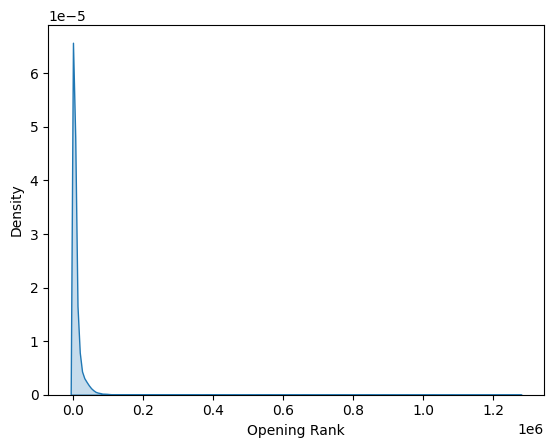

In [69]:
sns.kdeplot(df['Opening Rank'], label='Opening Rank', shade=True)

<Axes: xlabel='Opening Rank', ylabel='Density'>

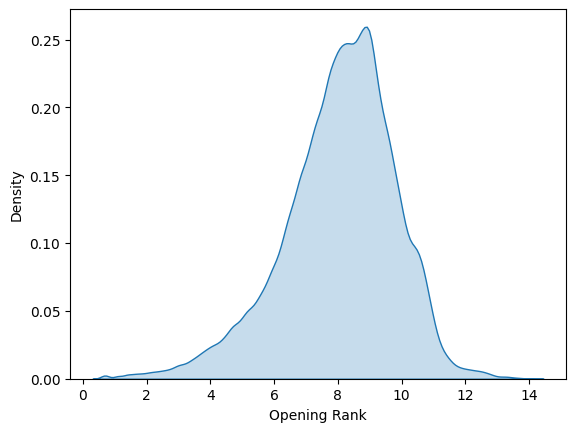

In [70]:
dff=df.copy()
dff['Opening Rank'] = np.log1p(dff['Opening Rank'])
sns.kdeplot(dff['Opening Rank'], label='Opening Rank', fill=True)
# sns.kdeplot(df['Closing Rank'], label='Closing Rank', fill=True)
# sns.kdeplot(df['Institute_TargetEnc'], label='Institute Target Enc', fill=True)
# sns.kdeplot(df['Branch_TargetEnc'], label='Branch Target Enc', fill=True)
# sns.kdeplot(df['Seat Type_TargetEnc'], label='Seat Type Target Enc', fill=True)

| Feature Type        | Action                      |
| ------------------- | --------------------------- |
| Opening Rank        | 🔥 Log        |
| Closing Rank        | 🔥 Log |
| Institute_FreqEnc   | 🔥 Log + Standardize        |
| Branch_FreqEnc      | 🔥 Log + Standardize        |
| appeared_candidates      | 🔥 Log + Standardize        |
| Institute_TargetEnc | ✅ Standardize               |
| Branch_TargetEnc    | ✅ Standardize               |
| Seat Type_TargetEnc | ✅ Standardize               |
| Year                | ✅ Standardize               |
| Round               | ✅ Standardize               |
| Duration            | ✅ Standardize               |
| Gender_*            | ❌ No change                 |
| Quota_*             | ❌ No change                 |


In [71]:

from sklearn.preprocessing import StandardScaler


standarizer_en={}
def StandardizeColumn(df: pd.DataFrame, col: str):
    sts=StandardScaler()
    sts.fit(df[[col]])
    standarizer_en[col]=sts
    standardized = sts.transform(df[[col]]).flatten()
    return standardized

def log_transform_column(df: pd.DataFrame, col: str):
    log_transformed = np.log1p(df[col])  # log1p to handle zero values
    return log_transformed




In [72]:
df['Opening Rank'] = np.log1p(df['Opening Rank'])
df['Closing Rank'] = np.log1p(df['Closing Rank'])
df['Institute_FreqEnc']=log_transform_column(df, 'Institute_FreqEnc')
df['Institute_FreqEnc']=StandardizeColumn(df, 'Institute_FreqEnc')

df['Branch_FreqEnc']=log_transform_column(df, 'Branch_FreqEnc')
df['Branch_FreqEnc']=StandardizeColumn(df, 'Branch_FreqEnc')

df['appeared_candidates']=log_transform_column(df, 'appeared_candidates')
df['appeared_candidates']=StandardizeColumn(df, 'appeared_candidates')



df['Institute_TargetEnc']=StandardizeColumn(df, 'Institute_TargetEnc')
df['Branch_TargetEnc']=StandardizeColumn(df, 'Branch_TargetEnc')

df['Seat Type_TargetEnc']=StandardizeColumn(df, 'Seat Type_TargetEnc')
df['Year']=StandardizeColumn(df, 'Year')
df['Round']=StandardizeColumn(df, 'Round')
df['Duration']=StandardizeColumn(df, 'Duration')



In [73]:
df

,Opening Rank,Closing Rank,Year,Round,Duration,appeared_candidates,Institute_TargetEnc,Institute_FreqEnc,Branch_TargetEnc,Branch_FreqEnc,Seat Type_TargetEnc,Gender_femaleonly,Gender_genderneutral,Quota_ai,Quota_ap,Quota_go,Quota_hs,Quota_jk,Quota_la,Quota_os
0,9.116799,9.496872,1.000321,0.263175,-0.374082,1.323257,-0.537694,-0.111695,0.954623,0.722067,1.864880,False,True,True,False,False,False,False,False,False
1,9.813946,9.958070,1.000321,0.263175,-0.374082,1.323257,-0.537376,-0.111695,0.944089,0.722067,1.855276,True,False,True,False,False,False,False,False,False
2,7.522400,7.652546,1.000321,0.263175,-0.374082,1.323257,-0.537694,-0.111695,0.954623,0.722067,-0.516742,False,True,True,False,False,False,False,False,False
3,8.046549,8.246958,1.000321,0.263175,-0.374082,1.323257,-0.537376,-0.111695,0.944089,0.722067,-0.514467,True,False,True,False,False,False,False,False,False
4,8.181441,8.544614,1.000321,0.263175,-0.374082,1.323257,-0.535676,-0.111695,0.942107,0.722067,0.130518,False,True,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
467604,11.194757,11.429033,1.000321,-0.863725,2.673214,1.323257,0.852620,-3.779004,1.655116,-3.216064,1.853820,False,True,True,False,False,False,False,False,False
467605,9.630169,9.667639,1.000321,-0.863725,2.673214,1.323257,0.837576,-3.779004,2.269437,-3.216064,-0.516742,False,True,True,False,False,False,False,False,False
467606,10.297184,10.370267,1.000321,-0.863725,2.673214,1.323257,0.837954,-3.779004,2.152718,-3.216064,0.136755,False,True,True,False,False,False,False,False,False
467607,9.451481,9.609452,1.000321,-0.863725,2.673214,1.323257,0.837954,-3.779004,2.152718,-3.216064,-0.545591,False,True,True,False,False,False,False,False,False


In [74]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 467609 entries, 0 to 467608
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Opening Rank          467609 non-null  float64
 1   Closing Rank          467609 non-null  float64
 2   Year                  467609 non-null  float64
 3   Round                 467609 non-null  float64
 4   Duration              467609 non-null  float64
 5   appeared_candidates   467609 non-null  float64
 6   Institute_TargetEnc   467609 non-null  float64
 7   Institute_FreqEnc     467609 non-null  float64
 8   Branch_TargetEnc      467609 non-null  float64
 9   Branch_FreqEnc        467609 non-null  float64
 10  Seat Type_TargetEnc   467609 non-null  float64
 11  Gender_femaleonly     467609 non-null  bool   
 12  Gender_genderneutral  467609 non-null  bool   
 13  Quota_ai              467609 non-null  bool   
 14  Quota_ap              467609 non-null  bool   
 15  Quota_go   

In [75]:
bool_cols=df.select_dtypes(include=['bool']).columns

df[bool_cols] = df[bool_cols].astype(int)

In [76]:
import pickle

import os

os.makedirs('model_training_artifacts', exist_ok=True)
with open('model_training_artifacts/standarizers.pkl', 'wb') as f:
    pickle.dump(standarizer_en, f)


df.to_csv('model_training_artifacts/model_training_data.csv', index=False)    